In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image

In [3]:
#no need of llm here, just defining the rulebased workflow

In [4]:
class Batsmans(TypedDict):
    run: int
    ball: int
    four: int
    six: int
    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [5]:
def calculate_strike_rate(state: Batsmans) -> Batsmans:
    sr = (state['run'] / state['ball']) * 100
    return {"sr": sr}

In [6]:
def calculate_strike_bpb(state: Batsmans) -> Batsmans:
    bpb = state['ball'] / (state['four'] + state["six"])
    return {"bpb": bpb}

In [7]:
def calculate_boundary_percentage(state: Batsmans) -> Batsmans:
    boundary_percent = (((state['four'] * 4) + (state['six'] * 6))/state['run'])*100
    return {"boundary_percentage": boundary_percent}

In [15]:
def Summary(state:Batsmans) -> Batsmans:
    summary = f"""
        Strike Rate - {state['sr']} \n
        Balls per boundary - {state['bpb']} \n
        boundary_percent - {state['boundary_percentage']} \n
    """

    return {'summary': summary}

In [16]:
graph = StateGraph(Batsmans)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_strike_bpb', calculate_strike_bpb)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('Summary', Summary)

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_strike_bpb')
graph.add_edge(START, 'calculate_boundary_percentage')
graph.add_edge('calculate_strike_rate', 'Summary')
graph.add_edge('calculate_strike_bpb', 'Summary')
graph.add_edge('calculate_boundary_percentage', 'Summary')

graph.add_edge('Summary', END)

workflow = graph.compile()

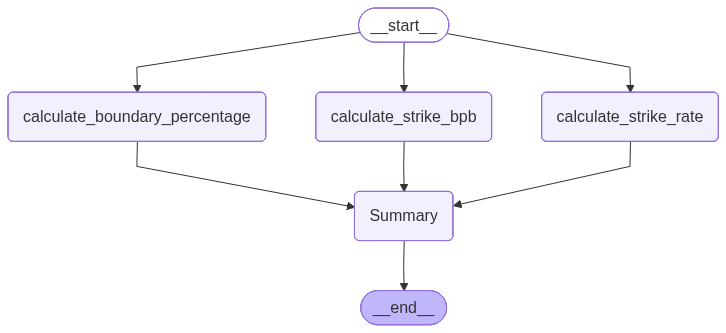

In [17]:
workflow

In [20]:
initial_state = {
    'run': 100,
    'ball': 50,
    'four': 7,
    'six': 4
}

In [21]:
workflow.invoke(initial_state)

{'run': 100,
 'ball': 50,
 'four': 7,
 'six': 4,
 'sr': 200.0,
 'bpb': 4.545454545454546,
 'boundary_percentage': 52.0,
 'summary': '\n        Strike Rate - 200.0 \n\n        Balls per boundary - 4.545454545454546 \n\n        boundary_percent - 52.0 \n\n    '}